![Py4Eng](../logo.png)

# Calibration and conformal prediction - solutions
## Yoav Ram

Solutions to the three in-session exercises in [sessions/calibration.ipynb](../sessions/calibration.ipynb).

This notebook is self-contained: it reloads the cached logits and redefines the handful of helpers the exercises need, so it can be run on its own. It needs `../data/cub_effnetv2s_logits.npz`, which the session notebook produces.

In [1]:
%matplotlib inline
import matplotlib.pyplot as plt
from pathlib import Path

import numpy as np
import pandas as pd
import scipy.stats
import seaborn as sns

import jax
import jax.numpy as jnp
import keras
print('Keras:', keras.__version__, 'backend:', keras.backend.backend(), jax.default_backend())

SEED = 23
keras.utils.set_random_seed(SEED)
sns.set(style='white', context='talk')

ALPHA = 0.1
NBINS = 15

Keras: 3.15.1 backend: jax cpu


## Setup

The same cache, the same split, and the same helpers as the session notebook.

In [2]:
DATA_DIR = Path('../data')
cache = np.load(DATA_DIR / 'cub_effnetv2s_logits.npz')
labels = cache['labels']
logits = cache['finetune']
n = len(labels)

perm = np.random.default_rng(SEED).permutation(n)
calibration, validation = perm[: n // 2], perm[n // 2:]
y = labels[validation]
print('{:,} held-out images: {:,} calibration, {:,} validation'.format(n, len(calibration), len(validation)))

5,794 held-out images: 2,897 calibration, 2,897 validation


In [3]:
def probabilities(logits, T=1.0):
    z = np.asarray(logits) / T
    z = z - z.max(axis=1, keepdims=True)
    e = np.exp(z)
    return e / e.sum(axis=1, keepdims=True)

def reliability(prob, y, nbins=NBINS):
    confidence, prediction = prob.max(axis=1), prob.argmax(axis=1)
    hit = (prediction == y).astype(float)
    edges = np.linspace(0, 1, nbins + 1)
    which = np.clip(np.digitize(confidence, edges[1:-1]), 0, nbins - 1)
    rows = [(edges[b], edges[b + 1], (which == b).sum(),
             confidence[which == b].mean() if (which == b).any() else np.nan,
             hit[which == b].mean() if (which == b).any() else np.nan)
            for b in range(nbins)]
    return pd.DataFrame(rows, columns=['low', 'high', 'count', 'confidence', 'accuracy'])

def ece(prob, y, nbins=NBINS):
    bins = reliability(prob, y, nbins)
    weight = bins['count'] / bins['count'].sum()
    return float(np.nansum(weight * (bins.accuracy - bins.confidence).abs()))

def nll(prob, y):
    return float(-np.log(prob[np.arange(len(y)), y] + 1e-12).mean())

def nll_temperature(log_T, logits, y):
    logp = jax.nn.log_softmax(logits / jnp.exp(log_T), axis=1)
    return -jnp.mean(logp[jnp.arange(len(y)), y])

nll_grad = jax.jit(jax.grad(nll_temperature))

def fit_temperature(logits, y, eta=0.1, tol=1e-6):
    log_T = 0.0
    while True:
        step = eta * nll_grad(log_T, logits, y)
        log_T -= step
        if abs(step) < tol:
            return float(np.exp(log_T))

def conformal_quantile(prob, y, alpha=ALPHA):
    scores = 1 - prob[np.arange(len(y)), y]
    m = len(scores)
    k = int(np.ceil((m + 1) * (1 - alpha)))
    assert k <= m, 'alpha is too small for {:,} calibration points'.format(m)
    return float(np.sort(scores)[k - 1])

def prediction_sets(prob, qhat):
    return prob >= 1 - qhat

def coverage(sets, y):
    return float(sets[np.arange(len(y)), y].mean())

T = fit_temperature(logits[calibration], labels[calibration])
P = probabilities(logits, T)
print('fitted temperature T = {:.4f}'.format(T))

fitted temperature T = 0.6563


# Exercise 1: the $\alpha$ sweep

> Plot the mean set size against the target coverage $1 - \alpha$ for $\alpha \in \{0.01, 0.02, 0.05, 0.1, 0.15, 0.2\}$, refitting $\hat{q}$ each time on the calibration half. Confirm that the empirical coverage tracks the target. Where is the elbow in the curve, and what does its position tell you about the model? What would the curve look like for a perfect classifier, and for a model at chance? Then find what sets the ceiling: print how many calibration scores lie above $\hat{q}$ at each level and how large the largest scores are. *Which* images are choosing $\hat{q}$ when $\alpha$ is small, and what does that imply for a dataset whose labels are imperfect?

Only $\hat{q}$ depends on $\alpha$, so the sweep is one line inside a loop. The temperature is fitted once and reused - it has nothing to do with $\alpha$.

In [4]:
ALPHAS = (0.01, 0.02, 0.05, 0.1, 0.15, 0.2)

rows = []
for alpha in ALPHAS:
    qhat = conformal_quantile(P[calibration], labels[calibration], alpha=alpha)
    sets = prediction_sets(P[validation], qhat)
    sizes = sets.sum(axis=1)
    rows.append({'alpha': alpha, 'target': 1 - alpha, 'q-hat': qhat,
                 'coverage': coverage(sets, y), 'mean size': sizes.mean(),
                 'median size': np.median(sizes), 'singletons': (sizes == 1).mean()})

sweep = pd.DataFrame(rows).set_index('alpha')
print(sweep.to_string(float_format='{:.3f}'.format))

       target  q-hat  coverage  mean size  median size  singletons
alpha                                                             
0.01    0.990  1.000     0.991     33.274       21.000       0.036
0.02    0.980  0.999     0.981     14.497        8.000       0.115
0.05    0.950  0.991     0.949      4.587        3.000       0.305
0.10    0.900  0.956     0.905      2.062        1.000       0.505
0.15    0.850  0.890     0.855      1.427        1.000       0.669
0.20    0.800  0.788     0.807      1.122        1.000       0.829


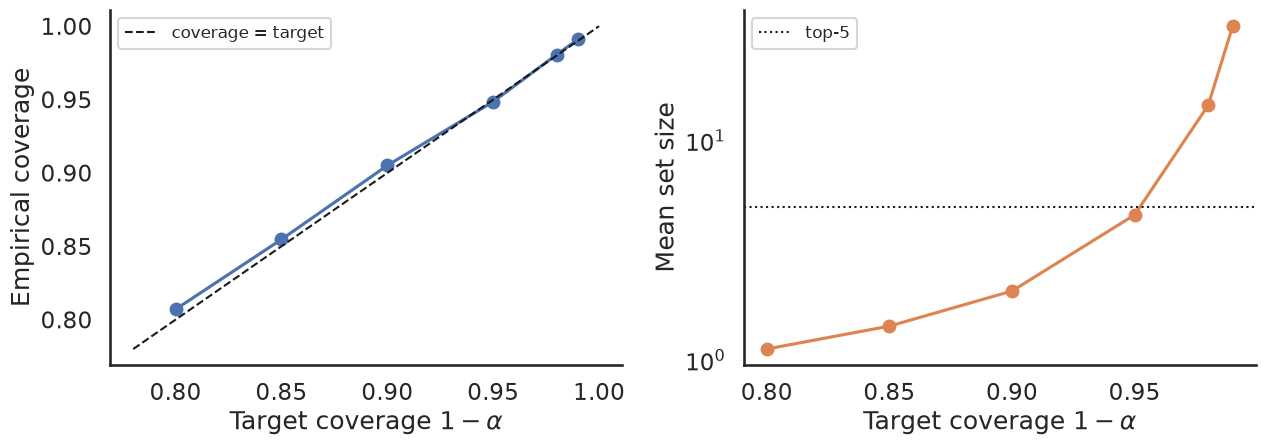

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.8))

ax = axes[0]
ax.plot(sweep.target, sweep.coverage, 'o-')
ax.plot([0.78, 1], [0.78, 1], ls='--', c='k', lw=1.5, label='coverage = target')
ax.set(xlabel='Target coverage $1 - \\alpha$', ylabel='Empirical coverage')
ax.legend(fontsize=12)

ax = axes[1]
ax.plot(sweep.target, sweep['mean size'], 'o-', c='C1')
ax.axhline(5, c='k', ls=':', lw=1.5, label='top-5')
ax.set(xlabel='Target coverage $1 - \\alpha$', ylabel='Mean set size', yscale='log')
ax.legend(fontsize=12)

fig.tight_layout()
sns.despine()

**Coverage tracks the target** at every level, to within half a percentage point - which is the whole claim of split conformal prediction, now verified at six values of $\alpha$ rather than one.

**The elbow is between 95% and 98%.** Going from 90% to 95% coverage costs us a mean set size of 2.06 to 4.59, a bit more than double. Going from 95% to 98% costs 4.59 to 14.50, and the last step to 99% costs 33.27 - a sixth of the 200 species, on average, per image. Note the log scale on the right-hand panel: past the elbow the curve is roughly a straight line on that scale, i.e. the set size is growing *exponentially* in the coverage we demand.

The position of the elbow is a statement about **the tail of the model's conformity scores**. $\hat{q}$ is a quantile of $1 - p(y \mid x)$ on the calibration set, so pushing $\alpha$ down means reaching further into the tail of images where the model gave the true species almost no probability. Our model has a long tail of those - it is 76% accurate on a 200-way problem - and to catch them the threshold has to fall so low that hundreds of irrelevant species come along.

The two limiting cases make the shape obvious:

- A **perfect classifier** that puts probability 1 on the truth every time has all conformity scores equal to 0. Then $\hat{q} = 0$ at every $\alpha$, the set is `{k : p(k|x) >= 1}`, and the curve is flat at size 1 all the way to $1 - \alpha = 1$. There is no elbow, because there is no tail.
- A **model at chance**, outputting the uniform distribution, has every score equal to $1 - 1/200$. The threshold is $1 - \hat q = 1/200$, every class clears it, and every set contains all 200 species at every $\alpha$. The curve is flat at 200. Again no elbow - a degenerate one this time, because the tail is everything.

Real models sit between these, and the elbow is where the useful part of the probability ranking runs out. Reading it off is a genuinely useful way to choose an operating point: 95% coverage at 4.6 candidates is a usable bird-identification aid, and 99% coverage at 33 candidates is not.

## What sets the ceiling

The elbow is really a statement about a handful of images, and we can count them.

In [6]:
scores = np.sort(1 - P[calibration, labels[calibration]])
m = len(scores)

print('alpha   rank of q-hat    q-hat      scores above it')
for alpha in ALPHAS:
    k = int(np.ceil((m + 1) * (1 - alpha)))
    print('{:.2f}    {:4d} / {:,}     {:.6f}   {:3d}'.format(alpha, k, m, scores[k - 1], m - k))

print()
print('calibration scores above 0.99:   {:3d}'.format((scores > 0.99).sum()))
print('calibration scores above 0.999:  {:3d}'.format((scores > 0.999).sum()))
print('calibration scores above 0.9999: {:3d}'.format((scores > 0.9999).sum()))
print('the 5 most extreme: the model gave the labelled species {}'.format(
    ', '.join('{:.1e}'.format(p) for p in 1 - scores[-5:])))

alpha   rank of q-hat    q-hat      scores above it
0.01    2870 / 2,897     0.999688    27
0.02    2841 / 2,897     0.998646    56
0.05    2754 / 2,897     0.990769   143
0.10    2609 / 2,897     0.956020   288
0.15    2464 / 2,897     0.890419   433
0.20    2319 / 2,897     0.788424   578

calibration scores above 0.99:   148
calibration scores above 0.999:   46
calibration scores above 0.9999:  20
the 5 most extreme: the model gave the labelled species 4.8e-06, 3.8e-06, 2.9e-06, 2.6e-06, 1.8e-06


At $\alpha = 0.1$, $\hat{q}$ is the 2,609th of 2,897 scores, with 288 above it - a genuine quantile, estimated from hundreds of images, and robust to any one of them.

At $\alpha = 0.01$ it is the 2,870th, with **27** above it, and those 27 are all above 0.9999. The threshold has walked out into a tail where the model gave the labelled species a probability of order $10^{-6}$. So $1 - \hat{q} \approx 3 \times 10^{-4}$, every class with more than a 0.03% chance enters the set, and the mean size explodes to 33.

**Which images are those?** Exactly the kind we met in §1. An image where a well-fitted model assigns the labelled class a probability of $10^{-6}$ is either a genuinely bizarre photograph or a **mislabelled** one - and §1 found that two of six confident errors were arguably the dataset's. Conformal prediction is doing precisely what we asked: to cover the labelled class 99% of the time, it must cover the mislabels too, and the only way to cover a class the model has ranked near-last is to admit almost everything.

Two things follow.

1. **Label noise sets a practical ceiling on $1 - \alpha$.** Past roughly the noise rate of your labels, you are no longer buying coverage of real birds; you are buying coverage of transcription errors, and paying for it in set size across every image. The elbow sits near where that begins.
2. **This is a property of the data, not a flaw in the method.** The guarantee is about the labels you gave it. Asking for 99% coverage of a label set that is not 99% correct is asking for something the sets cannot usefully provide, and the exploding set size is the procedure telling you so.

It also suggests the honest diagnostic: if your sets blow up at small $\alpha$, go and look at the calibration images with the largest scores before you blame the model.

# Exercise 2: probe versus fine-tune

> The cache contains `probe`, the logits of the linear probe from `transfer.ipynb` - same backbone, frozen, with a softmax regression on top, and trained **without** label smoothing. Fit its temperature, and compare NLL, ECE and mean set size at $\alpha = 0.1$ against the fine-tune. Does the fitted temperature support the explanation given in §3? Then note the gap in top-1 accuracy and the gap in mean set size, and say which is the bigger difference between these two models.

Everything is model-agnostic, so this is the same pipeline pointed at a different array of logits.

In [7]:
def evaluate(logits, name):
    T = fit_temperature(logits[calibration], labels[calibration])
    raw, cal = probabilities(logits), probabilities(logits, T)
    qhat = conformal_quantile(cal[calibration], labels[calibration])
    sets = prediction_sets(cal[validation], qhat)
    sizes = sets.sum(axis=1)
    return {
        'model': name, 'T': T,
        'top-1': (cal[validation].argmax(axis=1) == y).mean(),
        'NLL (T=1)': nll(raw[validation], y), 'NLL': nll(cal[validation], y),
        'ECE (T=1)': ece(raw[validation], y), 'ECE': ece(cal[validation], y),
        'mean size': sizes.mean(), 'singletons': (sizes == 1).mean(),
        'coverage': coverage(sets, y),
    }

models = pd.DataFrame([evaluate(cache['probe'], 'Linear probe'),
                       evaluate(cache['finetune'], 'Fine-tune')]).set_index('model')
print(models.to_string(float_format='{:.4f}'.format))

                  T  top-1  NLL (T=1)    NLL  ECE (T=1)    ECE  mean size  singletons  coverage
model                                                                                          
Linear probe 0.9365 0.6697     1.2133 1.2090     0.0419 0.0193     3.3614      0.2503    0.9092
Fine-tune    0.6563 0.7646     1.1370 0.9287     0.2070 0.0149     2.0625      0.5054    0.9051


**The temperature supports the explanation.** The probe, trained with plain categorical cross-entropy and no label smoothing, wants $T = 0.94$ - essentially 1, the model as trained. The fine-tune, trained with `label_smoothing=0.1`, wants $T = 0.66$. The two share the same backbone weights as a starting point, the same data and the same split, and they differ sharply in exactly the direction label smoothing predicts.

That is evidence, not proof. The two models also differ in capacity, in what was allowed to move during training, and in how much they overfit, and we did not run the controlled experiment - retraining the probe *with* label smoothing and watching $T$ fall - because this notebook trains nothing. But look how much smaller the miscalibration is to begin with: the probe's uncalibrated ECE is 0.042 against the fine-tune's 0.207, a factor of five. The probe barely needs calibrating.

The rest of the table is the real point of the exercise.

In [8]:
probe_row, finetune_row = models.loc['Linear probe'], models.loc['Fine-tune']

print('top-1 accuracy: {:.1%} -> {:.1%}   ({:+.1%}, a factor of {:.2f})'.format(
    probe_row['top-1'], finetune_row['top-1'],
    finetune_row['top-1'] - probe_row['top-1'], finetune_row['top-1'] / probe_row['top-1']))
print('mean set size:  {:.2f}  -> {:.2f}    (a factor of {:.2f})'.format(
    probe_row['mean size'], finetune_row['mean size'],
    probe_row['mean size'] / finetune_row['mean size']))
print('singletons:     {:.1%} -> {:.1%}'.format(probe_row['singletons'], finetune_row['singletons']))

top-1 accuracy: 67.0% -> 76.5%   (+9.5%, a factor of 1.14)
mean set size:  3.36  -> 2.06    (a factor of 1.63)
singletons:     25.0% -> 50.5%


**The set size is the bigger difference, by a long way.**

On accuracy, fine-tuning buys 9.5 percentage points - a real gain, the one `transfer.ipynb` reported, but a 1.14x improvement. On set size at the same 90% coverage it buys 3.36 candidates down to 2.06, a 1.63x improvement, and the fraction of images resolved to a *single* species goes from 25% to 51% - exactly double. Twice as many birds get identified outright.

Both models are covered at 90%, because conformal prediction guarantees that for any model. So the coverage column is uninformative and the set size is where the entire difference between these two models shows up. That is the general lesson: **once coverage is fixed by construction, set size becomes the model-quality metric** - and it measures something accuracy cannot express, namely how well the model's whole probability ranking is ordered, not just whether the top entry is right.

The practical reading: a 9-point accuracy gap sounds incremental. "Half your birds identified outright instead of a third" is what that gap actually buys a user, and you only see it by asking for sets.

# Exercise 3: coverage is itself random

> Our 90.5% came from one particular random split. Redo the split 200 times on the cached logits - refitting $\hat{q}$ on each new calibration half and measuring coverage on the matching validation half - and histogram the 200 realised coverages. Where is it centred, and how wide is it? The guarantee is a statement about the draw of the calibration set; explain what that means for the single number we reported in §4.

Each replicate is a fresh permutation, a fresh $\hat{q}$ from the new calibration half, and a fresh coverage measurement on the new validation half. We hold the temperature fixed at the one fitted in the session, so that the only thing varying is the conformal split.

In [9]:
REPLICATES = 200
rng = np.random.default_rng(SEED)

coverages = np.empty(REPLICATES)
for r in range(REPLICATES):
    shuffled = rng.permutation(n)
    cal, val = shuffled[: n // 2], shuffled[n // 2:]
    qhat = conformal_quantile(P[cal], labels[cal])
    coverages[r] = coverage(prediction_sets(P[val], qhat), labels[val])

print('mean   {:.4f}'.format(coverages.mean()))
print('sd     {:.4f}'.format(coverages.std()))
print('range  {:.4f} to {:.4f}'.format(coverages.min(), coverages.max()))
print('below the {:.0%} target: {:.1%} of replicates'.format(1 - ALPHA, (coverages < 1 - ALPHA).mean()))

mean   0.9011
sd     0.0074
range  0.8840 to 0.9203
below the 90% target: 44.5% of replicates


Centred essentially on the target, and spread by about 0.7 percentage points, with individual replicates as low as 88.4% and as high as 92.0%.

The spread is not a defect and it is not noise in our measurement - it is *predicted by the theory*, and we can draw the prediction on top of the histogram. Conditional on the calibration set, the coverage of split conformal prediction is exactly
$$
\text{Coverage} \mid \text{calibration set} \; \sim \; \text{Beta}(k,\; m + 1 - k), \qquad k = \lceil (m+1)(1-\alpha) \rceil ,
$$
for $m$ calibration points ([Angelopoulos & Bates 2023](https://arxiv.org/abs/2107.07511), §3.2). That distribution has mean $k / (m+1) \ge 1 - \alpha$, which is the guarantee, and a standard deviation that shrinks like $1/\sqrt{m}$.

theory : mean 0.9003, sd 0.0056
measured mean 0.9011, sd 0.0074
sd expected once the finite validation half is included: 0.0079


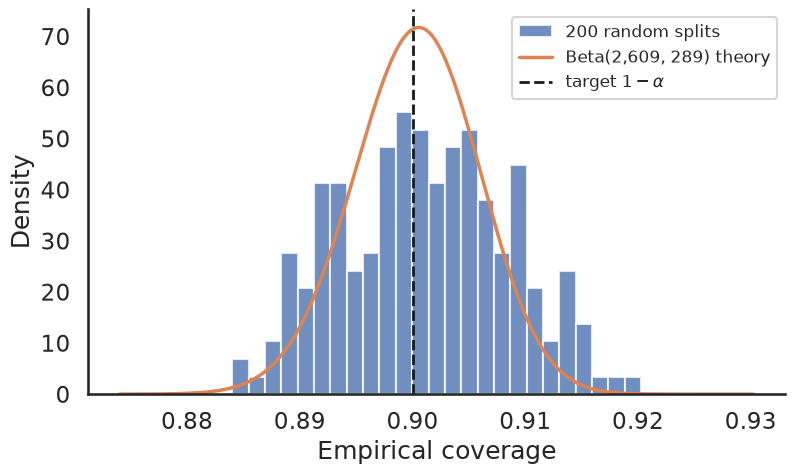

In [10]:
m = len(calibration)
k = int(np.ceil((m + 1) * (1 - ALPHA)))
beta = scipy.stats.beta(k, m + 1 - k)

fig, ax = plt.subplots(figsize=(9, 5))
ax.hist(coverages, bins=25, density=True, color='C0', alpha=0.8, label='{} random splits'.format(REPLICATES))
grid = np.linspace(coverages.min() - 0.01, coverages.max() + 0.01, 400)
ax.plot(grid, beta.pdf(grid), c='C1', lw=2.5, label='Beta({:,}, {}) theory'.format(k, m + 1 - k))
ax.axvline(1 - ALPHA, c='k', ls='--', lw=2, label='target $1 - \\alpha$')
ax.set(xlabel='Empirical coverage', ylabel='Density')
ax.legend(fontsize=12)
sns.despine()

print('theory : mean {:.4f}, sd {:.4f}'.format(beta.mean(), beta.std()))
print('measured mean {:.4f}, sd {:.4f}'.format(coverages.mean(), coverages.std()))
print('sd expected once the finite validation half is included: {:.4f}'.format(
    np.sqrt(beta.std() ** 2 + (1 - ALPHA) * ALPHA / len(validation))))

The Beta curve sits under the histogram, a little narrower than it. That gap is expected and is our doing, not the theory's: the Beta describes the *true* coverage probability for a given calibration set, whereas each of our 200 numbers is that probability estimated from a finite validation half of 2,897 images, which adds binomial noise of its own. Adding the two variances gives a standard deviation of about 0.0079 against our measured 0.0074 - consistent.

**What this means for the 90.5% we reported in §4.**

That number was one draw from this histogram. It was never a promise that the procedure covers at 90.5%; it was a sample from a distribution centred a hair above 90%. Had the session notebook used `SEED = 24` we might have printed 89.2% instead, and nothing would have been wrong.

So be careful about the object the guarantee describes. $P(Y \in C(X)) \ge 1 - \alpha$ is a probability over the joint draw of *everything*: the calibration set and the new point together. It does **not** say that the coverage you achieve with the particular calibration set sitting on your disk is at least $1 - \alpha$ - here, 45% of the replicates came in below 90%. What it says is that if you repeated the whole exercise many times, you would average at or above the target.

Two practical consequences:

1. **Do not tune the split.** Resampling the calibration/validation split until the coverage looks good is exactly the same error as picking the seed that makes your accuracy highest. You would be selecting from this histogram, not improving anything.
2. **Bigger calibration sets pay off twice.** More calibration data narrows this histogram as $1/\sqrt{m}$, so your realised coverage lands closer to what you asked for - and $\hat{q}$ itself is estimated from a longer tail, so the sets get less erratic. With $m = 2{,}897$ we are within about a point either way; with $m = 200$ the spread would be roughly four times wider, and a "90% guarantee" would routinely deliver 82%.

# Colophon
This notebook was written by [Yoav Ram](http://python.yoavram.com).

This work is licensed under a CC BY-NC-SA 4.0 International License.

![Python logo](https://www.python.org/static/community_logos/python-logo.png)